#  **Requested vs Approved Quantity Analysis: Exploratory data analysis**

This exploratory data analysis prepares the dataset for statistical hypothesis testing by examining the relationship between quantity_requested and quantity_approved. The objective is to understand:
* the distribution
* variability
* missingness
* outliers
* and group-level behavior
of the allocation gap before any statistical tests

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import seaborn as sns 

In [27]:
df=pd.read_csv('../data/requisitions_cleaned.csv')

In [28]:
df.head()

,product_primary_name,processing_periods_name,facility_type_name,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size,zone,dispensing_unit
0,PYRA-COMP,2025-05-01,HEALTH CENTER,290.0,22.0,10.0,980.0,NaN,NaN,313,2.0,1,DISTRICT25,TABLET
1,PYRA-COMP,2025-05-01,HEALTH CENTER,3510.0,6.0,437.0,1426.0,NaN,0.0,246,151.0,1,DISTRICT28,TABLET
2,ART-INJ,2025-07-01,HEALTH CENTER,1744.0,4.0,409.0,1508.0,NaN,7396.0,-978,681.0,5,DISTRICT28,VIAL
3,RDT,2025-04-01,HEALTH CENTER,3187.0,737.0,471.0,3934.0,NaN,NaN,345,340.0,25,DISTRICT2,PIECE
4,PYRA-COMP,2025-07-01,HEALTH CENTER,3665.0,0.0,706.0,2667.0,NaN,5338.0,-1042,332.0,1,DISTRICT23,TABLET


## Dealing with missing values

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31742 entries, 0 to 31741
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_primary_name          31742 non-null  object 
 1   processing_periods_name       31742 non-null  object 
 2   facility_type_name            31742 non-null  object 
 3   beginning_balance             31742 non-null  float64
 4   quantity_received             31742 non-null  float64
 5   quantity_dispensed            31742 non-null  float64
 6   stock_in_hand                 31742 non-null  float64
 7   quantity_requested            8751 non-null   float64
 8   quantity_approved             25782 non-null  float64
 9   total_losses_and_adjustments  31742 non-null  int64  
 10  amc                           31742 non-null  float64
 11  pack_size                     31742 non-null  int64  
 12  zone                          31742 non-null  object 
 13  d

Event though the df.info() does not show missing values, we can observe that the columns **quantity_requested** 
and **quantity_approved** have missing values. 
* As explained during the data preparation phase, this is not necessarily a data quality issue.
It could be instead business logic related issue. eg. The NaN or empty values in the quantityrequested means that the facility did not place an order and the associated quantityapproved could also be empty if the approval team is OK with the decision
* Although missing values are observed in quantity_requested and quantity_approved (The NaN or empty values), these do not necessarily represent data quality issues. Due to the quarterly ordering structure of the supply chain, missing requested quantities often correspond to periods in which facilities did not place orders.
* Similarly, records where both requested and approved quantities are missing likely represent non-ordering events rather than incomplete data.
* However, records containing a requested quantity without a corresponding approved quantity may indicate unresolved approvals, delayed data entry, synchronization issues, or incomplete workflow processing.

To avoid introducing bias into the statistical analysis, missing approved quantities will not be automatically replaced with zero. Instead, the hypothesis testing dataset is restricted to observations where both requested and approved quantities were available, ensuring valid paired comparisons.

### Create sub-dataframe for ordering months only and relevant observations

In [30]:
print(df["processing_periods_name"].dtype)

object


In [31]:
df["processing_periods_name"] = pd.to_datetime(
    df["processing_periods_name"]
)
print(df["processing_periods_name"].dtype)

datetime64[ns]


In [32]:
# Define ordering months
ordering_months = [2, 5, 8, 11]
# Filter dataframe
df_ordering_months = df[
    df["processing_periods_name"].dt.month.isin(ordering_months)
].copy()

In [33]:
df_ordering_months.head()

,product_primary_name,processing_periods_name,facility_type_name,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size,zone,dispensing_unit
0,PYRA-COMP,2025-05-01,HEALTH CENTER,290.0,22.0,10.0,980.0,NaN,NaN,313,2.0,1,DISTRICT25,TABLET
1,PYRA-COMP,2025-05-01,HEALTH CENTER,3510.0,6.0,437.0,1426.0,NaN,0.0,246,151.0,1,DISTRICT28,TABLET
8,ACT-GC,2025-05-01,HEALTH CENTER,89.0,1.0,57.0,65.0,NaN,620.0,209,20.0,30,DISTRICT28,BLISTER
10,ACT-AD,2024-02-01,HEALTH CENTER,4125.0,2604.0,1423.0,6554.0,NaN,13.0,-179,1464.0,30,DISTRICT33,BLISTER
12,ART-SUP,2024-08-01,HEALTH CENTER,20.0,0.0,2.0,185.0,NaN,0.0,-456,0.0,2,DISTRICT36,CAPSULE


In [34]:
conditions = {
    "no_order_event":
        df_ordering_months["quantity_requested"].isna() &
        df_ordering_months["quantity_approved"].isna(),

    "valid_order":
        df_ordering_months["quantity_requested"].notna() &
        df_ordering_months["quantity_approved"].notna(),

    "requested_only":
        df_ordering_months["quantity_requested"].notna() &
        df_ordering_months["quantity_approved"].isna(),

    "approved_only":
        df_ordering_months["quantity_requested"].isna() &
        df_ordering_months["quantity_approved"].notna()
}
for name, cond in conditions.items():
    print(name, cond.sum())

no_order_event 1421
valid_order 2420
requested_only 557
approved_only 6343


We will discard in this dataset the **'no_order_event' and 'requested_only'** since we considered them
as orders that miss approval

In [35]:
conditions = {
    "valid_order":
        df_ordering_months["quantity_requested"].notna() &
        df_ordering_months["quantity_approved"].notna(),
    "approved_only":
        df_ordering_months["quantity_requested"].isna() &
        df_ordering_months["quantity_approved"].notna()
}
# Create subdatasets for each condition
df_analysis = df_ordering_months[
    conditions["valid_order"] |
    conditions["approved_only"]
].copy()
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8763 entries, 1 to 31739
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   product_primary_name          8763 non-null   object        
 1   processing_periods_name       8763 non-null   datetime64[ns]
 2   facility_type_name            8763 non-null   object        
 3   beginning_balance             8763 non-null   float64       
 4   quantity_received             8763 non-null   float64       
 5   quantity_dispensed            8763 non-null   float64       
 6   stock_in_hand                 8763 non-null   float64       
 7   quantity_requested            2420 non-null   float64       
 8   quantity_approved             8763 non-null   float64       
 9   total_losses_and_adjustments  8763 non-null   int64         
 10  amc                           8763 non-null   float64       
 11  pack_size                     8763

### Descriptive comparison of requested vs approved quantities

We are not testing raw dataset in the Hypothesis testing but we are also testing the difference between the quantity_requested and quantity_approved in sense.

In [36]:
df_analysis["diff"] = df_analysis["quantity_approved"] - df_analysis["quantity_requested"].fillna(0)

In [37]:
df_analysis.head(20)

,product_primary_name,processing_periods_name,facility_type_name,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size,zone,dispensing_unit,diff
1,PYRA-COMP,2025-05-01,HEALTH CENTER,3510.0,6.0,437.0,1426.0,NaN,0.0,246,151.0,1,DISTRICT28,TABLET,0.0
8,ACT-GC,2025-05-01,HEALTH CENTER,89.0,1.0,57.0,65.0,NaN,620.0,209,20.0,30,DISTRICT28,BLISTER,620.0
10,ACT-AD,2024-02-01,HEALTH CENTER,4125.0,2604.0,1423.0,6554.0,NaN,13.0,-179,1464.0,30,DISTRICT33,BLISTER,13.0
12,ART-SUP,2024-08-01,HEALTH CENTER,20.0,0.0,2.0,185.0,NaN,0.0,-456,0.0,2,DISTRICT36,CAPSULE,0.0
14,RDT,2024-02-01,HEALTH CENTER,2243.0,0.0,535.0,2167.0,NaN,319.0,420,583.0,25,DISTRICT15,PIECE,319.0
15,ACT-SC,2024-05-01,HEALTH CENTER,1346.0,0.0,82.0,600.0,NaN,2.0,-278,33.0,30,DISTRICT16,BLISTER,2.0
19,ACT-INF,2025-11-01,HEALTH CENTER,796.0,418.0,244.0,453.0,NaN,12.0,598,22.0,30,DISTRICT20,BLISTER,12.0
22,ART-INJ,2025-08-01,HEALTH CENTER,719.0,43.0,293.0,2401.0,NaN,424.0,112,420.0,5,DISTRICT4,VIAL,424.0
24,ART-INJ,2024-02-01,HEALTH CENTER,885.0,0.0,268.0,541.0,NaN,2398.0,461,82.0,5,DISTRICT21,VIAL,2398.0
25,RDT,2025-05-01,HEALTH CENTER,1.0,0.0,0.0,2.0,NaN,0.0,-30,0.0,25,DISTRICT33,PIECE,0.0


In [38]:
df_analysis.columns

Index(['product_primary_name', 'processing_periods_name', 'facility_type_name',
       'beginning_balance', 'quantity_received', 'quantity_dispensed',
       'stock_in_hand', 'quantity_requested', 'quantity_approved',
       'total_losses_and_adjustments', 'amc', 'pack_size', 'zone',
       'dispensing_unit', 'diff'],
      dtype='object')

In [39]:
#Rename the columns
df_analysis_quantities=df_analysis[['product_primary_name', 'processing_periods_name', 'facility_type_name',
'quantity_requested', 'quantity_approved','pack_size','dispensing_unit','diff']].copy()
df_analysis_quantities.rename(columns={'diff':'allocation_gap'},inplace=True)
df_analysis_quantities.head()

,product_primary_name,processing_periods_name,facility_type_name,quantity_requested,quantity_approved,pack_size,dispensing_unit,allocation_gap
1,PYRA-COMP,2025-05-01,HEALTH CENTER,NaN,0.0,1,TABLET,0.0
8,ACT-GC,2025-05-01,HEALTH CENTER,NaN,620.0,30,BLISTER,620.0
10,ACT-AD,2024-02-01,HEALTH CENTER,NaN,13.0,30,BLISTER,13.0
12,ART-SUP,2024-08-01,HEALTH CENTER,NaN,0.0,2,CAPSULE,0.0
14,RDT,2024-02-01,HEALTH CENTER,NaN,319.0,25,PIECE,319.0


In [40]:
df_analysis_quantities.describe()

,processing_periods_name,quantity_requested,quantity_approved,pack_size,allocation_gap
count,8763,2420.000000,8763.000000,8763.000000,8763.000000
mean,2024-12-20 14:40:57.514549760,745.470661,832.614401,180.924227,626.744380
min,2024-02-01 00:00:00,17.000000,0.000000,1.000000,-2628.000000
25%,2024-08-01 00:00:00,391.000000,1.000000,5.000000,0.000000
50%,2025-02-01 00:00:00,639.000000,42.000000,30.000000,9.000000
75%,2025-08-01 00:00:00,1004.250000,597.000000,30.000000,426.000000
max,2025-11-01 00:00:00,2950.000000,52652.000000,1000.000000,49702.000000
std,NaN,487.625668,2075.873748,362.624183,2081.540296


This summary table already provides several strong indications about the behavior of the approval process, even before conducting formal hypothesis testing.
* The average approved quantity (832.6) is higher than the average requested quantity (745.5). This suggests that, on average, the system tends to approve more than is requested. However, the difference is relatively small (87 units higher) compared to the very large standard deviation of approved quantities (2,075.9), indicating substantial variability between observations.
* The medians tell a very different story, Median approved quantity is 42 compared to 639 for requested quantity. This suggests that, at least 50% of observations of approved quantities are substantially lower than requested quantities. Mean = 832.6 and Median = 42 exhibits by the approved quantity is is an enormous gap. This indicates most approvals are relatively small and there is a number of extremely large approvals are pulling the mean upward, as confirmed by max approved quantity= 52,652 versus 75th percentile =597.
**This apparent contradiction between the mean and median is a strong indication of a highly skewed distribution.**
* In the allocation_gap, the median gap (9) indicates that 50% of typical observations between the quantity_requested and quantity_approved are actually very close to balance, With 25% of them have no positive allocation gap at all (25th percentile = 0). 25% of the the requested quantities have been fullfilled for all products accross all facilities types.

From a supply chain perspective, the results do not necessarily imply that the programs routinely supplies more than facilities request.
Instead, the statistics suggest the coexistence of two different processes:
* Most facilities appear to receive quantities that are equal  or slightly different to  their requested quantities
* A smaller number of observations receive very large approved quantities, creating extremely high positive allocation gaps. These observations may correspond to: emergency distributions, mass distribution activities (e.g., ITNs), or observations where no request was recorded but stock was supplied. 


## Data visualization

We will use data visualization to understand their distributions and assess them

### Requested vs approved quantities

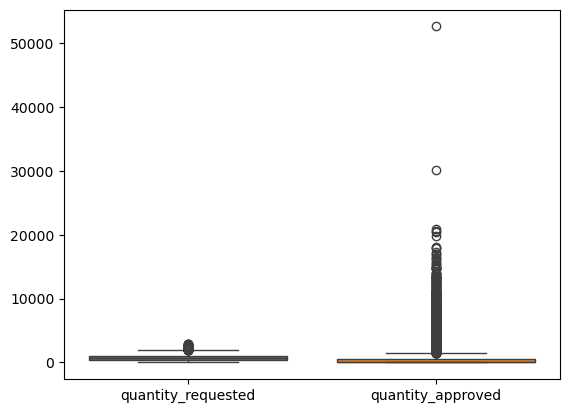

In [41]:
sns.boxplot(data=df_analysis_quantities[["quantity_requested", "quantity_approved"]])
plt.show()

The boxplot provides a visual confirmation of the patterns observed in the descriptive statistics and highlights a substantial difference in the distribution of requested and approved quantities. The distribution of quantity_approved is highly skewed and characterized by numerous extreme values compared to the quantity requested.

While requested quantities rarely exceed 3,000 units, approved quantities extend beyond 50,000 units, creating a very long right tail. These extreme approvals compress the central portion of the distribution and pull the mean upward, explaining why the mean approved quantity exceeds the mean requested quantity despite a much lower median.

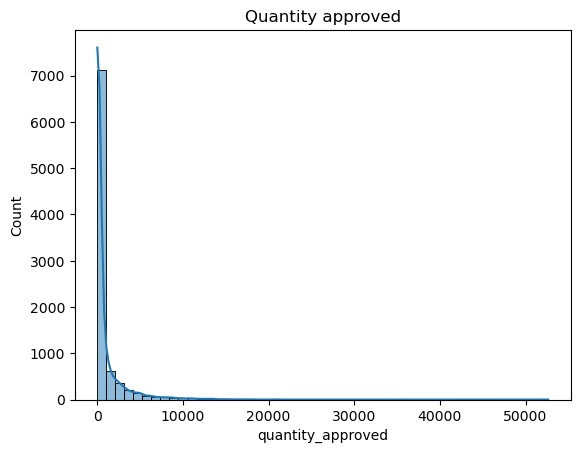

In [42]:
sns.histplot(df_analysis_quantities["quantity_approved"], bins=50, kde=True)
plt.title('Quantity approved');
plt.show()

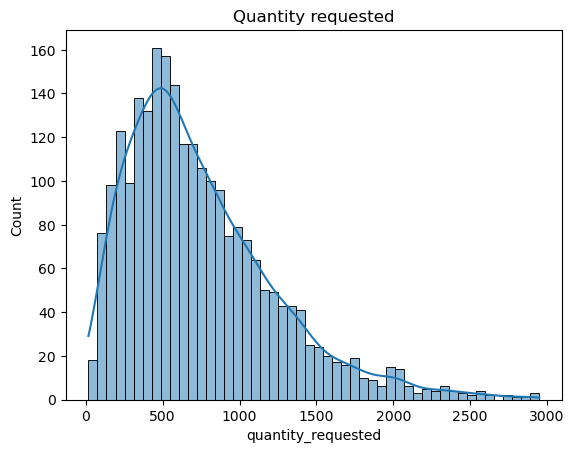

In [43]:
sns.histplot(df_analysis_quantities["quantity_requested"], bins=50, kde=True)
plt.title('Quantity requested');
plt.show()

### Allocation Gap

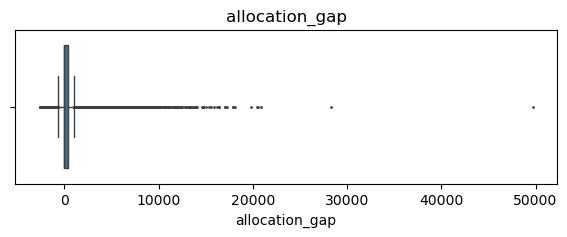

In [45]:
# Create box plot of beginning_balance
plt.figure(figsize=(7,2))
plt.title('allocation_gap')
sns.boxplot(data=None, x=df_analysis_quantities['allocation_gap'], fliersize=1);

### Quantification of the outliers detection

In [46]:
percentile75=df_analysis_quantities['allocation_gap'].quantile(0.75)
percentile25=df_analysis_quantities['allocation_gap'].quantile(0.25)
IQR=percentile75-percentile25
upper_limit = percentile75 + 1.5 * IQR
lower_limit = percentile25 - 1.5 * IQR
print ('IQR ',IQR)
print ('Outlier threshold upper limit',upper_limit)
print('Outlier threshold lower limit',lower_limit)
nb_upper_outliers=len(df_analysis_quantities[df_analysis_quantities['allocation_gap'] > upper_limit])
nb_lower_outliers=len(df_analysis_quantities[df_analysis_quantities['allocation_gap'] < lower_limit])
total_number_obs=df_analysis_quantities.shape[0]
proportion_outliers=((nb_upper_outliers+nb_lower_outliers)/total_number_obs)*100
print ('Total number of outliers',(nb_upper_outliers+nb_lower_outliers))
print('Proportion of outlier',f"{proportion_outliers:.2f}")

IQR  426.0
Outlier threshold upper limit 1065.0
Outlier threshold lower limit -639.0
Total number of outliers 2167
Proportion of outlier 24.73


* The distribution of allocation_gap exhibits a strong right-skewed pattern, indicating that the difference between approved and requested quantities 
is highly uneven across observations. With the interquartile range (IQR) lies approximately between 0  and 426 , with a median of 9 units, This suggests that at least 50% of observations have allocation gaps ranging from no difference to moderate positive differences, indicating that approved quantities are often close to requested quantities for a large proportion of records
* However, the distribution also contains extreme positive values extending up to approximately 49,702 units, creating a pronounced long right tail.The standard deviation (2082) is more than three times larger than the mean (~627), confirming very high variability and the presence of extreme values.
* At the lower end, negative values down to -2,628 units indicate situations where approved quantities were substantially lower than requested quantities.
* To quantify the extent of these extreme observations, an outlier analysis was conducted using the Interquartile Range (IQR) method. The resulting outlier thresholds were −639 units for the lower limit and 1,065 units for the upper limit. Based on these thresholds, 2,167 observations were classified as outliers, representing approximately 24.7% of all records. This proportion is considerably higher than what is typically observed in moderately skewed distributions and confirms that the allocation gap distribution is both heavy-tailed and highly dispersed. The large number of outliers suggests that extreme allocation differences are not isolated events but rather a recurring characteristic of the dataset.
* From a purely statistical perspective, these observations would be classified as outliers, reflecting a heavy-tailed and highly dispersed distribution rather than a symmetric allocation pattern.
* From a supply chain perspective, these extreme positive allocation gaps indicate situations where facilities received substantially more stock than formally requested. Since the analysis includes records where quantity_requested was missing and treated as zero, part of these positive differences may correspond to emergency allocations, direct distributions, redistribution activities, or inventory supplied outside the routine ordering workflow.
* It is important to note that these outliers should not automatically be interpreted as data errors.

In this dataset, facilities operate at different levels (e.g., health centers vs. district or regional hospitals), leading to substantial variation in stockholding capacity. Products are distributed in different dispensing units and pack sizes, ranging from small units (e.g., blister packs of 30 tablets) to bulk formats (e.g., cartons containing up to 1000 tablets). As a result, identical “quantities” in reporting terms may correspond to vastly different physical volumes, inflating values for certain products.

Given that,  we would like to explore the approach to analyze outliers within homogeneous groups defined by product and facility type.

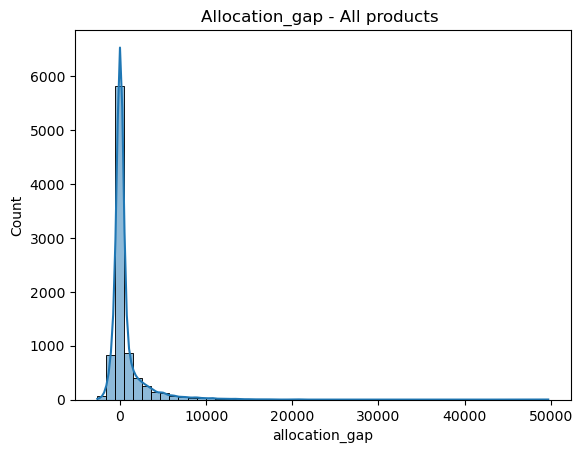

In [47]:
sns.histplot(df_analysis_quantities["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap - All products ');
plt.show()

#### Outlier detection by category

In [48]:
df_product_dispensingunit_unique = df_analysis_quantities[['product_primary_name', 'dispensing_unit','pack_size']].drop_duplicates().reset_index(drop=True)
df_product_dispensingunit_unique

,product_primary_name,dispensing_unit,pack_size
0,PYRA-COMP,TABLET,1
1,ACT-GC,BLISTER,30
2,ACT-AD,BLISTER,30
3,ART-SUP,CAPSULE,2
4,RDT,PIECE,25
5,ACT-SC,BLISTER,30
6,ACT-INF,BLISTER,30
7,ART-INJ,VIAL,5
8,ITN,PIECE,50
9,QUIN,TABLET,1000


Based on the recommendation above we will analyze the outlier by products group of similar dispensing unit, groups (therapeutic group) within different by facilities type.
Products will be group below based on they homogeneity:
* ACT-INF,ACT-SC,ACT-GC,ACT-AD: group of product for the treatment of uncomplicated Malaria using the same dispensing units. This group will be called Group ACT
* PYRA-COMP,PYRA-SAC: Group of product for the treatment of uncomplicated Malaria even though they don't use the same dispensing units by their packsize are the same.  This group will be called Group PYRA
* ART-INJ,ART-SUP: Both forms are used for treating severe malaria, although they serve different roles in the treatment process. Their dispensing unit are similar. This group will be called Group ART
* QUIN and SP: Even though they used for treatment of different type of malaria (Severe and uncomplicated/prevention) they use the same dispensing unit and they have the same packsize. This group will be called Group SP
* ITN and RDT: are used respectively for prevention and diagnosis of malaria. As they are not treatment and use the same dispensing unit we will group them. This group will be called Group PREV

##### Outliers analyis of Group ACT products

<Axes: xlabel='product_primary_name', ylabel='allocation_gap'>

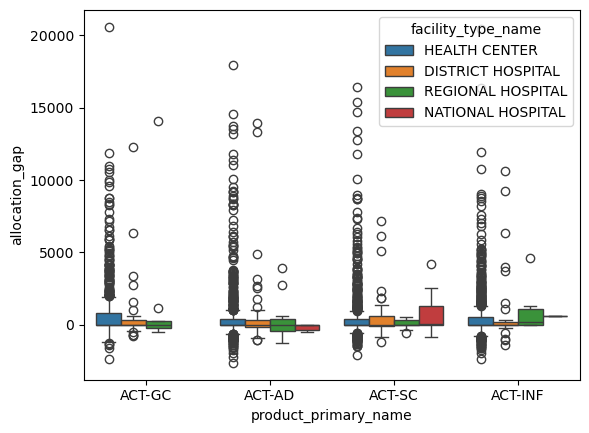

In [49]:
group_act=['ACT-INF','ACT-SC','ACT-GC','ACT-AD']
df_group_act=df_analysis_quantities[df_analysis_quantities['product_primary_name'].isin(group_act)]
sns.boxplot(
    data=df_group_act,
    x="product_primary_name",
    y="allocation_gap",
    hue="facility_type_name"
)

In [50]:
def compute_percentiles(df, facility_type, column='allocation_gap'):
    df_subset = df[df['facility_type_name'] == facility_type]
    p25 = df_subset[column].quantile(0.25)
    p75 = df_subset[column].quantile(0.75)
    iqr = p75 - p25
    upper = p75 + 1.5 * iqr
    lower = p25 - 1.5 * iqr
    nb_upper_outliers=len(df_subset[df_subset[column]>upper])
    total_number_obs=df_subset.shape[0]
    #print('Number of outlier',nb_upper_outliers)
    #print('total number',total_number_obs)
    proportion_outliers=(nb_upper_outliers/total_number_obs)*100
    return {
        'facility_type': facility_type,
        'p25': p25,
        'p75': p75,
        'iqr': iqr,
        'upper_limit': upper,
        'lower_limit': lower,
        'nb_outlier': nb_upper_outliers,
        'tot_observations': total_number_obs,
        'proportion_outliers': proportion_outliers,
        
    }

In [51]:
results = []
for ft in df_group_act['facility_type_name'].unique():
    res = compute_percentiles(df_group_act, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,0.00,488.75,488.75,1221.875,-733.125,464,2726,17.021277
1,DISTRICT HOSPITAL,0.00,354.50,354.50,886.250,-531.750,31,166,18.674699
2,REGIONAL HOSPITAL,0.00,405.00,405.00,1012.500,-607.500,6,37,16.216216
3,NATIONAL HOSPITAL,-111.25,383.75,495.00,1126.250,-853.750,3,16,18.750000


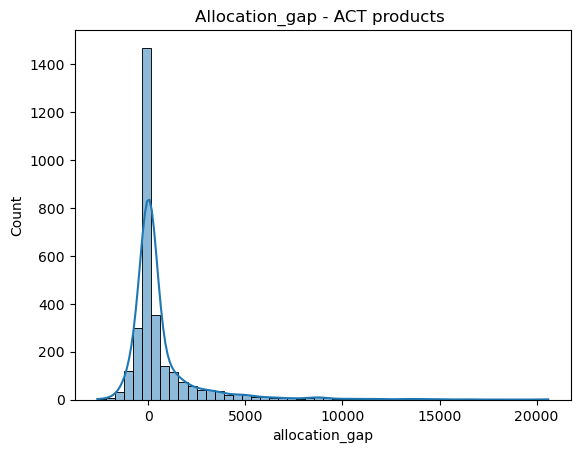

In [52]:
sns.histplot(df_group_act["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap - ACT products ');
plt.show()


* The boxplot graph show that positive Skew Exists Across All ACT Products and facility types. The persistence of this pattern across all ACT products suggests that the allocation decision of the products by the program is not product-specific but rather reflects a broader allocation behavior within the supply chain. While health centers contribute the largest number of outliers due to their greater representation in the dataset (2726), all facility types exhibit similar distributional patterns characterized by a concentration of observations near zero and a long positive tail.
* However, The stratified analysis of the ACT product group demonstrates that the proportion of outliers decreases substantially when observations are compared within homogeneous product and facility categories, falling from 24.7% in the overall dataset to approximately 16–19% across facility types. This suggest that Some observations appeared abnormal only because they were being compared with fundamentally different products and facility types.
* For Health Center,District and Regional Hospital, 25% of observations have allocation_gap = 0. It suggests that a substantial proportion of orders are fulfilled exactly as requested. However, the NATIONAL HOSPITAL shows different behavior. Approximately 25% of ACT orders submitted by National Hospitals have an allocation gap of −111 units or less, which means that 25% of the requested quantities of products at this level have been under fullfilled.
* The histogram confirm the previous analysis as it shows that The majority of allocation events resulted in small differences between approved and requested quantities, with allocation gaps clustered around zero. The frequency of observations falls away rapidly as the allocation gap increases, although a small number of orders received substantially larger approved quantities than requested, producing a long right tail that extends to nearly 20,000 units.

##### Outliers analyis of Group PYRA products

<Axes: xlabel='product_primary_name', ylabel='allocation_gap'>

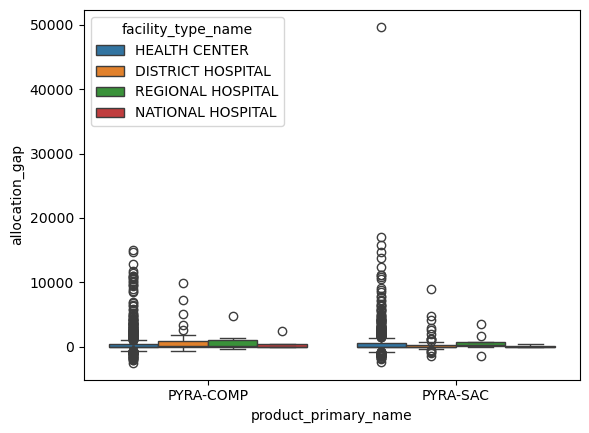

In [53]:
group_pyra=['PYRA-COMP','PYRA-SAC']
df_group_pyra=df_analysis_quantities[df_analysis_quantities['product_primary_name'].isin(group_pyra)]
sns.boxplot(
    data=df_group_pyra,
    x="product_primary_name",
    y="allocation_gap",
    hue="facility_type_name"
)

In [54]:
results = []
for ft in df_group_pyra['facility_type_name'].unique():
    res = compute_percentiles(df_group_pyra, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,0.0,499.00,499.00,1247.500,-748.500,197,1229,16.029292
1,DISTRICT HOSPITAL,0.0,720.50,720.50,1801.250,-1080.750,12,91,13.186813
2,REGIONAL HOSPITAL,10.0,1143.25,1133.25,2843.125,-1689.875,2,14,14.285714
3,NATIONAL HOSPITAL,0.0,354.00,354.00,885.000,-531.000,1,8,12.500000


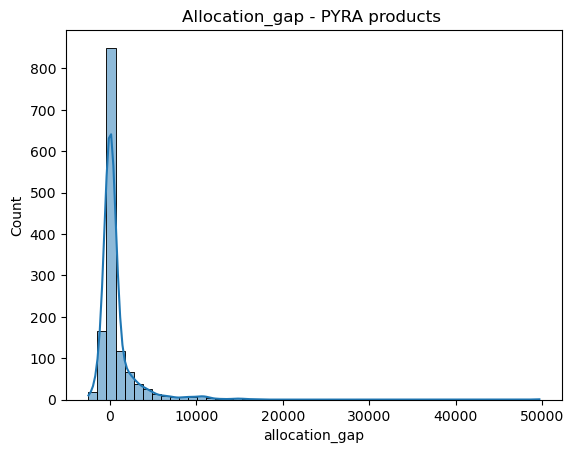

In [55]:
sns.histplot(df_group_pyra["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap - PYRA products ');
plt.show()

**The overall pattern remains similar with the other groups. The distribution is dominated by non-negative allocation gaps, indicating that approved quantities are frequently equal to or greater than recorded requests. (right-skewed distributions, P25 near zero, and the presence of positive outliers).**
* Compared with the ACT group, the PYRA group exhibits consistently lower proportions of outliers across all facility types.This may be associated with the higher demand and operational importance of first-line malaria treatments.
* Similarly to the ACT group, the histogram confirm the  analysis as it shows that The majority of allocation events resulted in small differences between approved and requested quantities, with allocation gaps clustered around zero. The frequency of observations falls away rapidly as the allocation gap increases, although a small number of orders received substantially larger approved quantities than requested, producing a long right tail that extends to nearly 50,000 units.


##### Outliers analyis of Group ART products

<Axes: xlabel='product_primary_name', ylabel='allocation_gap'>

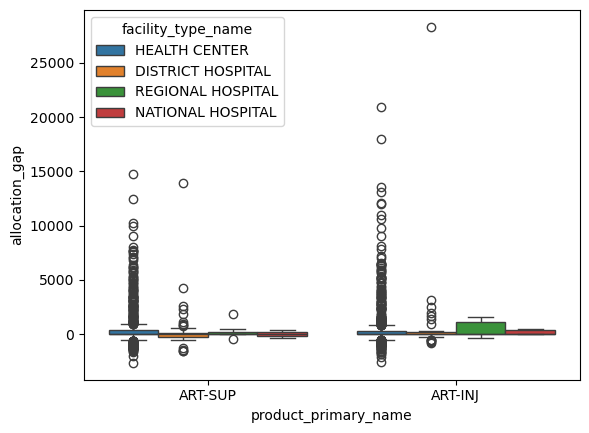

In [56]:
group_art=['ART-INJ','ART-SUP']
df_group_art=df_analysis_quantities[df_analysis_quantities['product_primary_name'].isin(group_art)]
sns.boxplot(
    data=df_group_art,
    x="product_primary_name",
    y="allocation_gap",
    hue="facility_type_name"
)

In [57]:
results = []
for ft in df_group_art['facility_type_name'].unique():
    res = compute_percentiles(df_group_art, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,0.0,356.50,356.50,891.250,-534.750,236,1412,16.713881
1,DISTRICT HOSPITAL,0.0,176.75,176.75,441.875,-265.125,17,92,18.478261
2,REGIONAL HOSPITAL,0.0,314.50,314.50,786.250,-471.750,3,16,18.750000
3,NATIONAL HOSPITAL,0.0,368.75,368.75,921.875,-553.125,0,8,0.000000


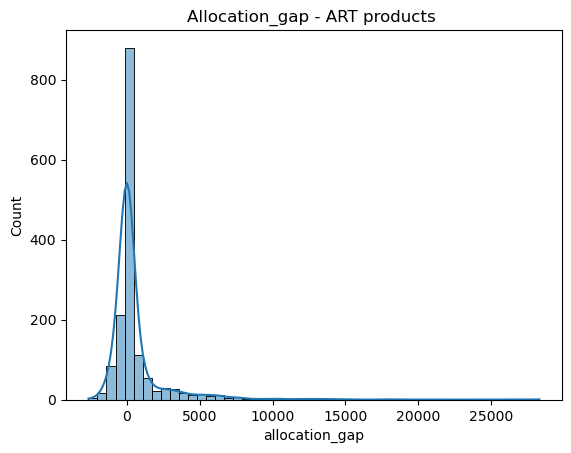

In [58]:
sns.histplot(df_group_art["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap - ART products ');
plt.show()

**The overall pattern remains similar with the other groups. The distribution is dominated by non-negative allocation gaps, indicating that approved quantities are frequently equal to or greater than recorded requests. (right-skewed distributions, P25 near zero, and the presence of positive outliers)**
* Compared with the ACT group, the ART group exhibits consistently lower proportions of outliers across all facility types.This may be associated with the higher demand and operational importance of first-line malaria treatments.
* Similarly to the ACT group, the histogram confirm the  analysis as it shows that The majority of allocation events resulted in small differences between approved and requested quantities, with allocation gaps clustered around zero. The frequency of observations falls away rapidly as the allocation gap increases, although a small number of orders received substantially larger approved quantities than requested, producing a long right tail that extends to nearly 25,000 units.
* National Hospitals behave differently with 0% outliers. However, it would be cautious to avoid making any substantive interpretation of the the results since This sample is far too small to draw strong conclusions (nb observation =8).

##### Outliers analyis of Group SP products

<Axes: xlabel='product_primary_name', ylabel='allocation_gap'>

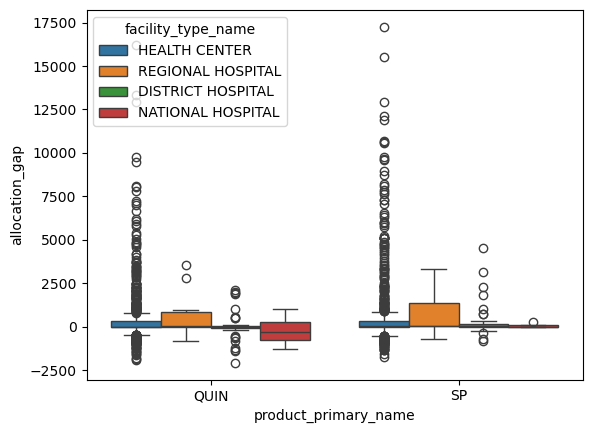

In [59]:
group_sp=['QUIN','SP']
df_group_sp=df_analysis_quantities[df_analysis_quantities['product_primary_name'].isin(group_sp)]
sns.boxplot(
    data=df_group_sp,
    x="product_primary_name",
    y="allocation_gap",
    hue="facility_type_name"
)

In [60]:
results = []
for ft in df_group_sp['facility_type_name'].unique():
    res = compute_percentiles(df_group_sp, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,0.0,330.75,330.75,826.875,-496.125,247,1322,18.683812
1,REGIONAL HOSPITAL,0.0,864.00,864.00,2160.000,-1296.000,3,25,12.000000
2,DISTRICT HOSPITAL,0.0,110.50,110.50,276.250,-165.750,16,79,20.253165
3,NATIONAL HOSPITAL,-144.0,68.75,212.75,387.875,-463.125,1,8,12.500000


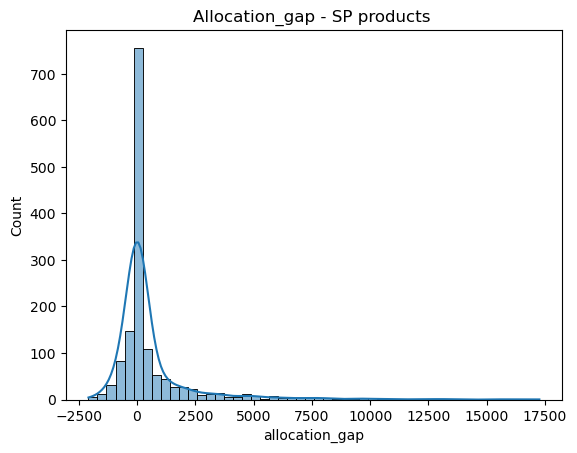

In [61]:
sns.histplot(df_group_sp["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap - SP products ');
plt.show()

**The overall pattern remains similar with the other groups. The distribution is dominated by non-negative allocation gaps, indicating that approved quantities are frequently equal to or greater than recorded requests. (right-skewed distributions, P25 near zero, and the presence of positive outliers)**
* Compared with the other product groups, the SP group exhibits some of the highest proportions of outliers among Health Centers (18.7%) and District Hospitals (20.3%). This suggests that while routine allocation decisions for SP products are generally stable, occasional large deviations between approved and requested quantities occur more frequently than for most other malaria commodity groups.
* Similarly to the ACT, PYRA, and ART groups, the histogram confirms that the majority of allocation events resulted in small differences between approved and requested quantities, with allocation gaps clustered around zero. The frequency of observations decreases rapidly as the allocation gap increases, although a small number of orders received substantially larger approved quantities than requested, producing a pronounced long right tail in the distribution.
* National Hospitals again behave differently, with a negative first quartile (P25 = -144), indicating that at least 25% of allocation events resulted in approved quantities lower than requested quantities. However, because this subgroup contains only 8 observations, caution should be exercised when interpreting the results, and no strong conclusions should be drawn regarding allocation behavior at this level.

##### Outliers analyis of Group PREV products

<Axes: xlabel='product_primary_name', ylabel='allocation_gap'>

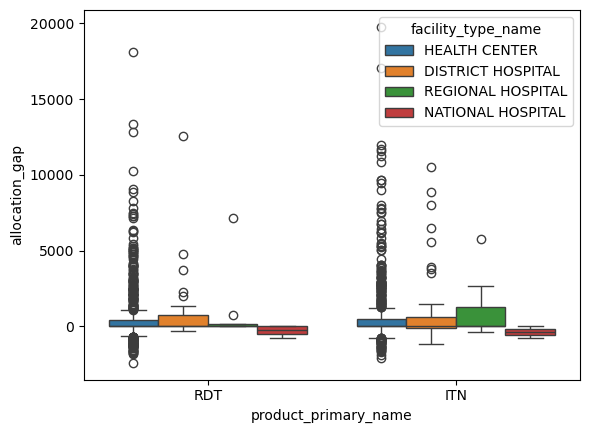

In [62]:
group_prev=['ITN','RDT']
df_group_prev=df_analysis_quantities[df_analysis_quantities['product_primary_name'].isin(group_prev)]
sns.boxplot(
    data=df_group_prev,
    x="product_primary_name",
    y="allocation_gap",
    hue="facility_type_name"
)

In [63]:
results = []
for ft in df_group_prev['facility_type_name'].unique():
    res = compute_percentiles(df_group_prev, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,0.0,475.75,475.75,1189.375,-713.625,225,1402,16.048502
1,DISTRICT HOSPITAL,0.0,766.25,766.25,1915.625,-1149.375,13,84,15.476190
2,REGIONAL HOSPITAL,0.0,614.75,614.75,1536.875,-922.125,4,22,18.181818
3,NATIONAL HOSPITAL,-683.5,5.25,688.75,1038.375,-1716.625,0,6,0.000000


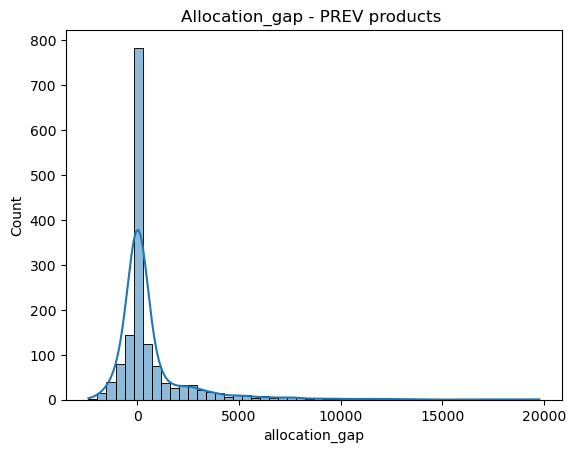

In [64]:
sns.histplot(df_group_prev["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap - PREV products ');
plt.show()

**The overall pattern remains similar with the other groups. The distribution is dominated by non-negative allocation gaps, indicating that approved quantities are frequently equal to or greater than recorded requests. (right-skewed distributions, P25 near zero, and the presence of positive outliers)**
* Compared with the other product groups, the PREV group exhibits relatively moderate proportions of outliers. This suggests that while routine allocation decisions for SP products are generally stable, occasional large deviations between approved and requested quantities occur more frequently than for most other malaria commodity groups.
* Similarly to the ACT, PYRA,SP, and ART groups, the histogram confirms that the majority of allocation events resulted in small differences between approved and requested quantities, with allocation gaps clustered around zero. The frequency of observations decreases rapidly as the allocation gap increases, although a small number of orders received substantially larger approved quantities than requested, producing a pronounced long right tail in the distribution.
* National Hospitals again behave differently, exhibiting the most negative first quartile observed across all product groups (P25 = -683.5). This indicates that at least 25% of allocation events resulted in approved quantities substantially lower than requested quantities. Unlike the ACT and SP groups, where the negative first quartile was relatively moderate, the magnitude observed in the PREV group suggests a stronger tendency toward under-allocation relative to recorded requests. This may reflect different allocation priorities for prevention and diagnostic commodities, particularly if these products are preferentially directed toward lower-level facilities where they are most frequently used. However, because this subgroup contains only 6 observations, caution should be exercised when interpreting the results, and no strong conclusions should be drawn regarding allocation behavior at this level.

#### Conclusion - Outliers analysis
Outlier analysis revealed that extreme allocation gaps persist even after stratification by product group and facility type, suggesting that they reflect genuine operational phenomena rather than data errors. Because these observations may correspond to emergency allocations, redistribution activities, stock shortages, or other meaningful supply chain events, they were retained in the primary analysis. Rather than removing or reassigning outliers, robust statistical methods that do not rely on normality assumptions were selected for hypothesis testing. A sensitivity analysis excluding outliers may be performed subsequently to assess the robustness of the findings.

## Demand and Allocation Profiling
To complement the exploratory data analysis, this section examines the distribution of requested and approved quantities across product groups and facility types during ordering periods. The objective is to identify which commodities drive the largest share of demand, which facility categories account for most orders, and how allocation decisions are distributed throughout the health supply chain. These analyses provide important operational context for interpreting subsequent hypothesis tests by highlighting the products and facility levels that contribute most to overall ordering and allocation patterns.

Key Questions Addressed
* Which product groups account for the largest share of requested quantities?
* Which product groups receive the largest share of approved quantities?
* Which facility types generate the highest demand?
* Which facility types receive the largest allocations?
* Are allocation patterns consistent with the observed demand profile?
* Which products and facility types are likely to drive the differences observed between requested and approved quantities?

### Which product groups account for the largest share of requested quantities?

### ACT Group

In [65]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors
# Creating a Green -> Yellow -> Red Gradient
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["green", "yellow", "red"]
)

In [66]:
product_order = ['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD']

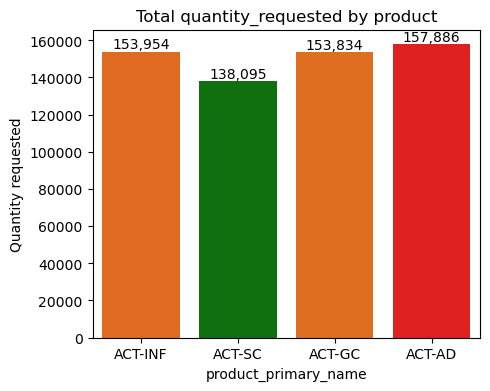

In [67]:
# Create bar plot of total quantities per products
plt.figure(figsize=(5,4))
qty_by_product= (
    df_group_act.groupby('product_primary_name')['quantity_requested']
      .sum()
      .sort_values(ascending=False)
)
qty_by_product=qty_by_product.reindex(index=product_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_product.min(),
    vmax=qty_by_product.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_product.values]
ax = sns.barplot(x=qty_by_product.index, y=qty_by_product.values,palette=bar_colors, hue=qty_by_product.index,
                 legend=False)
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Quantity requested')
plt.title('Total quantity_requested by product', fontsize=12);


In [68]:
max = np.max(qty_by_product)
min = np.min(qty_by_product)
percentage_difference = (abs(max - min)/ ((max + min )/2))*100
print (f"the percentage difference is {percentage_difference:.1f}")

the percentage difference is 13.4


* The total quantities requested differ slightly.ACT-AD accounts for the largest requested volume (157,886 units), while ACT-SC accounts for the lowest (138,095 units). The difference between the highest and lowest requested quantities is 19,791 representing 13.4 %
* This indicates that facilities tend to request larger quantities per order for some ACT formulations than for others

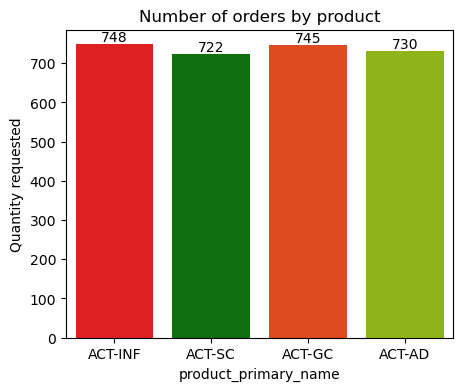

In [69]:
# Create bar plot of most frequently ordered products
plt.figure(figsize=(5,4))
orders_by_product= (
    df_group_act.groupby('product_primary_name')
      .size()
      .sort_values(ascending=False)
)
orders_by_product=orders_by_product.reindex(index=product_order)
norm = colors.Normalize(
    vmin=orders_by_product.min(),
    vmax=orders_by_product.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in orders_by_product.values]
ax = sns.barplot(x=orders_by_product.index, y=orders_by_product.values,palette=bar_colors, hue=orders_by_product.index,
                 legend=False)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Quantity requested')
plt.title('Number of orders by product', fontsize=12);

In [70]:
max = np.max(orders_by_product)
min = np.min(orders_by_product)
percentage_difference = (abs(max - min)/ ((max + min )/2))*100
print (f"the percentage difference is {percentage_difference:.1f}")

the percentage difference is 3.5


* the number of orders is remarkably balanced across all ACT formulations. The difference between the most frequently ordered product (ACT-INF, 748 orders) and the least frequently ordered product (ACT-SC, 722 orders) is only 26 orders, representing 3.5%  of the rate of difference
* From a supply chain perspective, this is expected because ACT products are often formulated for different patient groups (age). Health facilities therefore need to maintain stock of all formulations rather than relying on a single product.

**Comparing the two chart together: Average quantity requested per Order**

Let's calculatte the "Average quantity requested per order" by dividing the total orderd quantities by the number of orders by facility

In [71]:
df_avg_quantity_requested = pd.DataFrame({
    'Quantity requested': qty_by_product,
    'Nbr of orders': orders_by_product,
    'Average qty per order': round(qty_by_product / orders_by_product,1)
})
df_avg_quantity_requested=df_avg_quantity_requested.sort_values(by='Average qty per order', ascending=False)
df_avg_quantity_requested

,Quantity requested,Nbr of orders,Average qty per order
product_primary_name,,,
ACT-AD,157886.0,730,216.3
ACT-GC,153834.0,745,206.5
ACT-INF,153954.0,748,205.8
ACT-SC,138095.0,722,191.3


This suggests that facilities request ACT-AD in slightly larger quantities per order than the other ACT formulations, whereas ACT-SC tends to be requested in smaller quantities. 
From a supply chain perspective, the findings suggest a relatively balanced demand profile across the ACT family.

**General conclusion for ACT group**

The demand profile of ACT products reveals a relatively balanced distribution of ordering activity across all formulations. The  low % of difference in the number of orders per products indicating that all ACT formulations are routinely requested by health facilities. Total requested quantities are similarly distributed. While ACT-AD accounts for the highest requested volume and ACT-SC the lowest, the differences remain moderate relative to the overall demand based on the average quantity per order. 

Consequently, the allocation patterns and outlier behaviors previously observed are likely attributable to broader allocation practices rather than demand concentration in a specific ACT product.


### Which product groups receive the largest share of approved quantities?

### ACT Group

#### Total Approved Quantity by Product 

In [72]:
product_order = ['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD']

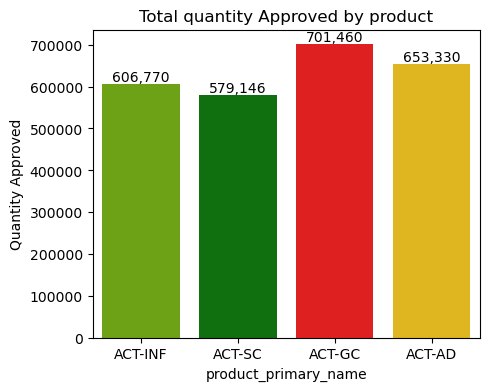

In [73]:
# Create bar plot of total quantities per products
plt.figure(figsize=(5,4))
qty_by_product= (
    df_group_act.groupby('product_primary_name')['quantity_approved']
      .sum()
      .sort_values(ascending=False)
)
qty_by_product=qty_by_product.reindex(index=product_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_product.min(),
    vmax=qty_by_product.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_product.values]
ax = sns.barplot(x=qty_by_product.index, y=qty_by_product.values,palette=bar_colors, hue=qty_by_product.index,
                 legend=False)
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Quantity Approved')
plt.title('Total quantity Approved by product', fontsize=12);


In [74]:
max = np.max(qty_by_product)
min = np.min(qty_by_product)
percentage_difference = (abs(max - min)/ ((max + min )/2))*100
print (f"The percentage difference is {percentage_difference:.1f}")

The percentage difference is 19.1


* The total quantities approved differ slightly accross the products group. ACT-GC accounts for the largest approved volume (701,460 units), while ACT-SC accounts for the lowest (576,146 units). The difference between the highest and lowest requested quantities 19%
* This indicates that the Medical Store allocates substantial quantities to all ACT formulations, with ACT-GC receiving approximately 19% more stock than ACT-SC, the least allocated product.

#### Requested Quantity vs Approved Quantity by Product Group

In [75]:
# Create bar plot of total quantities per products
plt.figure(figsize=(5,4))
qty_by_product= (
    df_group_act.groupby('product_primary_name')[['quantity_requested','quantity_approved']]
      .sum()
      .reset_index()
    
)
#qty_by_product=qty_by_product.reindex(index=product_order)
qty_by_product

,product_primary_name,quantity_requested,quantity_approved
0,ACT-AD,157886.0,653330.0
1,ACT-GC,153834.0,701460.0
2,ACT-INF,153954.0,606770.0
3,ACT-SC,138095.0,579146.0


<Figure size 500x400 with 0 Axes>

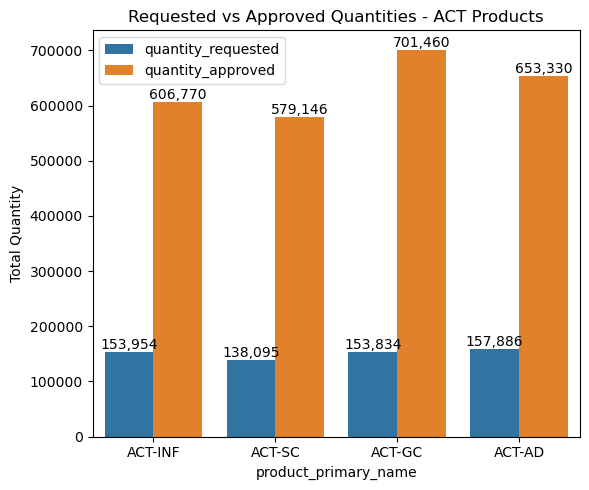

In [76]:
# Create bar plot of total quantities per products
plt.figure(figsize=(6,5))
qty_by_product= (
    df_group_act.groupby('product_primary_name')[['quantity_requested','quantity_approved']]
      .sum()
      .reset_index()
    
)
# Transform to long format for grouped bar chart
qty_by_product_long = qty_by_product.melt(
    id_vars='product_primary_name',
    value_vars=['quantity_requested', 'quantity_approved'],
    var_name='Type',
    value_name='Quantity'
)
ax = sns.barplot(
    data=qty_by_product_long,
    x='product_primary_name',
    y='Quantity',
    hue='Type',
    order=product_order
)

#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Total Quantity')
plt.title('Requested vs Approved Quantities - ACT Products', fontsize=12);
ax.legend(title='')
plt.tight_layout()
plt.show()

In [77]:
allocation_ratio =  pd.DataFrame({
    'product_primary_name':qty_by_product['product_primary_name'],
    'allocation_ratio':qty_by_product['quantity_approved']/qty_by_product['quantity_requested']
})

In [78]:
allocation_ratio

,product_primary_name,allocation_ratio
0,ACT-AD,4.137986
1,ACT-GC,4.559850
2,ACT-INF,3.941242
3,ACT-SC,4.193823


- The grouped bar chart clearly shows that, for all four ACT formulations, the total approved quantities substantially exceed the total requested quantities. While the requested quantities are relatively similar across products the approved quantities are approximately 4 to 5 times higher (allocation ration ranging from 3.9 to 4.5) the quantities formally requested for each ACT product.
- The allocation ratios indicate that the Medical Store distributed substantially more ACT commodities than were captured through the routine ordering process, likely reflecting direct distributions, emergency allocations, redistribution activities, or other operational supply mechanisms outside the standard facility ordering workflow.

### Which facility types generate the highest demand?

This section examines the distribution of demand across the different levels of the health system. The objective is to identify which facility types account for the largest share of requested quantities and whether the observed demand is driven primarily by the number of facilities or by higher ordering volumes per facility.

In [79]:
df_group_act['facility_type_name'].unique()

array(['HEALTH CENTER', 'DISTRICT HOSPITAL', 'REGIONAL HOSPITAL',
       'NATIONAL HOSPITAL'], dtype=object)

In [80]:
facility_order = ['HEALTH CENTER', 'DISTRICT HOSPITAL', 'REGIONAL HOSPITAL',
       'NATIONAL HOSPITAL']

#### Total Requested Quantity by Facility Type

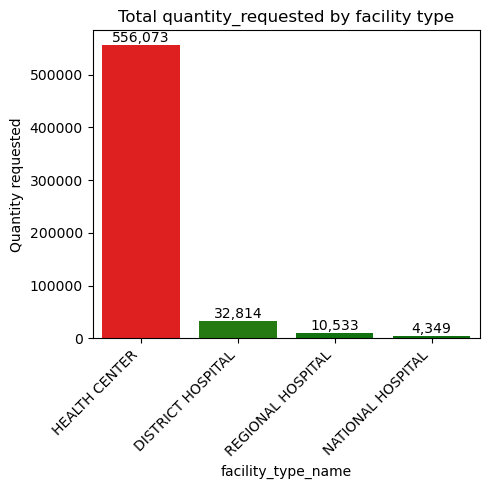

In [81]:
# Create bar plot of total quantities per products
plt.figure(figsize=(5,4))
qty_by_facility_type= (
    df_group_act.groupby('facility_type_name')['quantity_requested']
      .sum()
      .sort_values(ascending=False)
)
qty_by_facility_type=qty_by_facility_type.reindex(index=facility_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_facility_type.min(),
    vmax=qty_by_facility_type.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_facility_type.values]
ax = sns.barplot(x=qty_by_facility_type.index, y=qty_by_facility_type.values,palette=bar_colors, 
                 hue=qty_by_facility_type.index,
                 legend=False)
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Quantity requested')
plt.xticks(rotation=45, ha='right')
plt.title('Total quantity_requested by facility type', fontsize=12);

In [82]:
max_requested=qty_by_facility_type.max()
total_requested=qty_by_facility_type.sum()
percentage=(max_requested/total_requested)*100
print('Proportion of Health Center',f'{percentage:.2f}')

Proportion of Health Center 92.10


The chart shows that Health Centers generate by far the largest share of demand within the health supply chain, accounting for 556,073 requested units, which is more than 92% of the total requested quantity across all facility types.
Consequently, the Health Centers represent the main drivers of demand and are likely to have the greatest influence on the overall allocation patterns and the results of the subsequent hypothesis testing.

#### Number of Orders by Facility Type

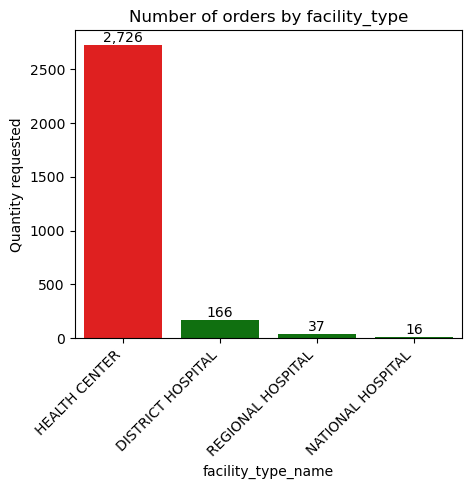

In [83]:
# Create bar plot of most frequently ordered products
plt.figure(figsize=(5,4))
orders_by_facility_type = (
    df_group_act.groupby('facility_type_name')
      .size()
      .sort_values(ascending=False)
)
orders_by_facility_type=orders_by_facility_type.reindex(index=facility_order)
norm = colors.Normalize(
    vmin=orders_by_product.min(),
    vmax=orders_by_product.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in orders_by_facility_type.values]
ax = sns.barplot(x=orders_by_facility_type.index, y=orders_by_facility_type.values,palette=bar_colors,
                 hue=orders_by_facility_type.index,
                 legend=False)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Quantity requested')
plt.xticks(rotation=45, ha='right')
plt.title('Number of orders by facility_type', fontsize=12);

In [84]:
max_requested=orders_by_facility_type.max()
total_requested=orders_by_facility_type.sum()
percentage=(max_requested/total_requested)*100
print('Proportion of Health Center',f'{percentage:.2f}')

Proportion of Health Center 92.56


92.56% of the orders are placed by the Health Center. This confirms that Health Centers are not only responsible for the largest requested quantities but also generate the highest volume of orders within the health supply chain.

This finding is consistent with the role of Health Centers as the primary point of care for malaria diagnosis and treatment, serving the largest patient population across the health system. Consequently, Health Centers are expected to have the greatest influence on overall demand patterns, allocation decisions, and the outcome of the subsequent hypothesis tests.

### Which facility types receive the largest allocations?

This section examines how approved quantities are distributed across facility types to identify which levels of the health system receive the largest allocations. By comparing allocation patterns with the demand profile presented previously, the analysis provides insight into whether the Medical Store distributes commodities proportionally to facility demand or whether certain facility types receive preferential or constrained allocations.

#### Total Approved  Quantity by Facility Type

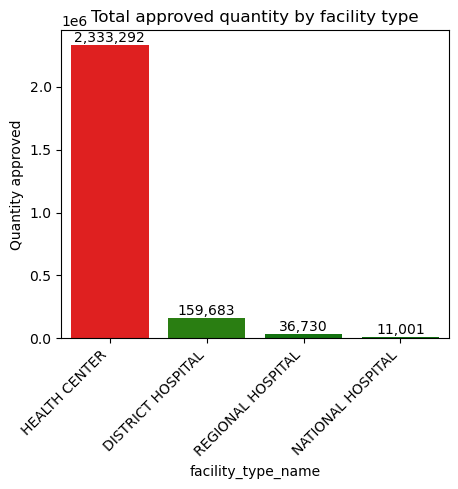

In [85]:
# Create bar plot of total quantities per products
plt.figure(figsize=(5,4))
qty_by_facility_type= (
    df_group_act.groupby('facility_type_name')['quantity_approved']
      .sum()
      .sort_values(ascending=False)
)
qty_by_facility_type=qty_by_facility_type.reindex(index=facility_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_facility_type.min(),
    vmax=qty_by_facility_type.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_facility_type.values]
ax = sns.barplot(x=qty_by_facility_type.index, y=qty_by_facility_type.values,palette=bar_colors, 
                 hue=qty_by_facility_type.index,
                 legend=False)
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Quantity approved')
plt.xticks(rotation=45, ha='right')
plt.title('Total approved quantity by facility type', fontsize=12);

In [86]:
max_requested=qty_by_facility_type.max()
total_approved=qty_by_facility_type.sum()
percentage=(max_requested/total_approved)*100
print('Proportion of Health Center',f'{percentage:.2f}')

Proportion of Health Center 91.84


The chart shows that Health Centers generate by far the largest share of approved quantities within the health supply chain, accounting for ~ 92% of the total approved quantity across all facility types. Reflecting their role as the principal providers of malaria diagnosis and treatment and the largest consumers of malaria commodities.

#### Requested vs Approved by Facility Type

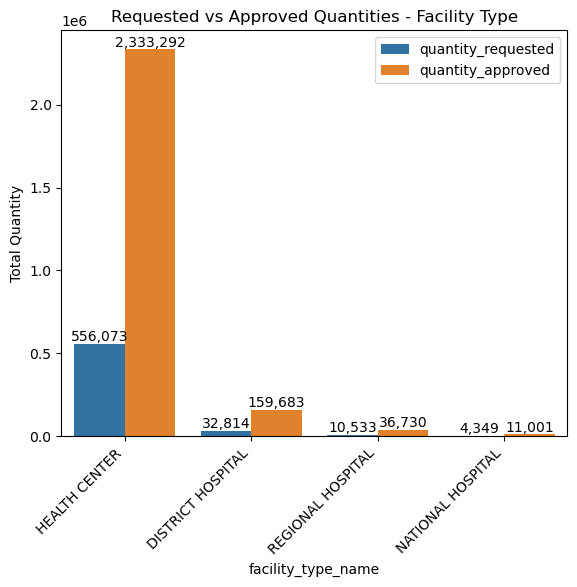

In [87]:
# Create bar plot of total quantities per products
plt.figure(figsize=(6,5))
qty_by_product= (
    df_group_act.groupby('facility_type_name')[['quantity_requested','quantity_approved']]
      .sum()
      .reset_index()
    
)
# Transform to long format for grouped bar chart
qty_by_product_long = qty_by_product.melt(
    id_vars='facility_type_name',
    value_vars=['quantity_requested', 'quantity_approved'],
    var_name='Type',
    value_name='Quantity'
)
ax = sns.barplot(
    data=qty_by_product_long,
    x='facility_type_name',
    y='Quantity',
    hue='Type',
    order=facility_order
)

#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
ax.set_ylabel('Total Quantity')
plt.title('Requested vs Approved Quantities - Facility Type', fontsize=12);
ax.legend(title='')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

* The comparison between requested and approved quantities shows that all facility types received substantially more commodities than were formally requested. This pattern is observed consistently across Health Centers, District Hospitals, Regional Hospitals, and National Hospitals, indicating that the difference between demand and allocation is systemic rather than limited to a particular level of the health system.
* Consequently, while the overall distribution of commodities across facility types generally aligns with the relative demand profile, the magnitude of approved quantities indicates that facility requests alone do not fully explain allocation decisions. This observation provides descriptive evidence that will be formally assessed during the subsequent hypothesis testing phase.